In [1]:
from google.colab import files
files.upload()

Saving kaggle (2).json to kaggle (2).json


{'kaggle (2).json': b'{"username":"mondipmech","key":"985e87350358e9e4db12ce49c8a3bc6c"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!pip install kaggle

!kaggle datasets download -d bhavikjikadara/dog-and-cat-classification-dataset
!unzip dog-and-cat-classification-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: PetImages/Dog/5499.jpg  
  inflating: PetImages/Dog/55.jpg    
  inflating: PetImages/Dog/550.jpg   
  inflating: PetImages/Dog/5500.jpg  
  inflating: PetImages/Dog/5501.jpg  
  inflating: PetImages/Dog/5502.jpg  
  inflating: PetImages/Dog/5503.jpg  
  inflating: PetImages/Dog/5504.jpg  
  inflating: PetImages/Dog/5505.jpg  
  inflating: PetImages/Dog/5506.jpg  
  inflating: PetImages/Dog/5507.jpg  
  inflating: PetImages/Dog/5508.jpg  
  inflating: PetImages/Dog/5509.jpg  
  inflating: PetImages/Dog/551.jpg   
  inflating: PetImages/Dog/5510.jpg  
  inflating: PetImages/Dog/5511.jpg  
  inflating: PetImages/Dog/5512.jpg  
  inflating: PetImages/Dog/5513.jpg  
  inflating: PetImages/Dog/5514.jpg  
  inflating: PetImages/Dog/5515.jpg  
  inflating: PetImages/Dog/5516.jpg  
  inflating: PetImages/Dog/5517.jpg  
  inflating: PetImages/Dog/5518.jpg  
  inflating: PetImages/Dog/5519.jpg  
  inflating: PetImages/Dog/552.jpg   

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import tqdm
import random
from keras.preprocessing.image import load_img
warnings.filterwarnings('ignore')

In [4]:
input_path = []
label = []

for class_name in os.listdir("PetImages"):
    for path in os.listdir("PetImages/"+class_name):
        if class_name == 'Cat':
            label.append(0)
        else:
            label.append(1)
        input_path.append(os.path.join("PetImages", class_name, path))
print(input_path[0], label[0])

PetImages/Cat/104.jpg 0


In [5]:
df = pd.DataFrame()
df['images'] = input_path
df['label'] = label
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,images,label
0,PetImages/Cat/11541.jpg,0
1,PetImages/Cat/4722.jpg,0
2,PetImages/Cat/3378.jpg,0
3,PetImages/Cat/7737.jpg,0
4,PetImages/Cat/4966.jpg,0


In [6]:
for i in df['images']:
    if '.jpg' not in i:
        print(i)

In [7]:
import PIL
l = []
for image in df['images']:
    try:
        img = PIL.Image.open(image)
    except:
        l.append(image)
l

[]

In [8]:
len(df)

24998

In [9]:
# to display grid of images
plt.figure(figsize=(25,25))
temp = df[df['label']==1]['images']
start = random.randint(0, len(temp))
files = temp[start:start+25]

for index, file in enumerate(files):
    plt.subplot(5,5, index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title('Dogs')
    plt.axis('off')

Output hidden; open in https://colab.research.google.com to view.

In [10]:
# to display grid of images
plt.figure(figsize=(25,25))
temp = df[df['label']==0]['images']
start = random.randint(0, len(temp))
files = temp[start:start+25]

for index, file in enumerate(files):
    plt.subplot(5,5, index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title('Cats')
    plt.axis('off')

Output hidden; open in https://colab.research.google.com to view.

<Axes: xlabel='label', ylabel='count'>

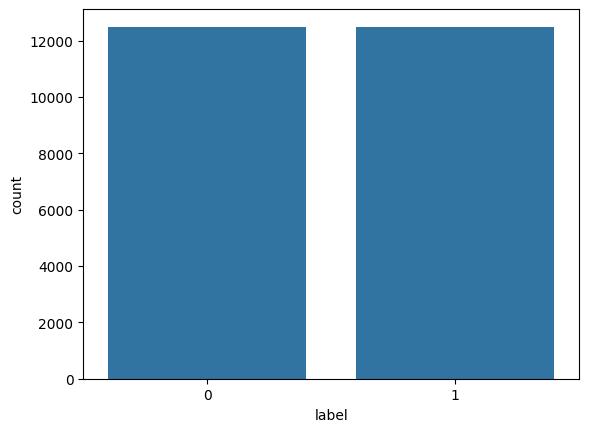

In [11]:
import seaborn as sns
sns.countplot(data=df, x='label')

In [12]:
df['label'] = df['label'].astype('str')

In [13]:
df.head()

,images,label
0,PetImages/Cat/11541.jpg,0
1,PetImages/Cat/4722.jpg,0
2,PetImages/Cat/3378.jpg,0
3,PetImages/Cat/7737.jpg,0
4,PetImages/Cat/4966.jpg,0


In [14]:
# input split
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, random_state=42)

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_generator = ImageDataGenerator(
    rescale = 1./255,  # normalization of images
    rotation_range = 40, # augmention of images to avoid overfitting
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

val_generator = ImageDataGenerator(rescale = 1./255)

train_iterator = train_generator.flow_from_dataframe(
    train,
    x_col='images',
    y_col='label',
    target_size=(128,128),
    batch_size=512,
    class_mode='binary'
)

val_iterator = val_generator.flow_from_dataframe(
    test,
    x_col='images',
    y_col='label',
    target_size=(128,128),
    batch_size=512,
    class_mode='binary'
)

Found 19998 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


In [16]:
from keras import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense

model = Sequential([
                    Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),
                    MaxPool2D((2,2)),
                    Conv2D(32, (3,3), activation='relu'),
                    MaxPool2D((2,2)),
                    Conv2D(64, (3,3), activation='relu'),
                    MaxPool2D((2,2)),
                    Flatten(),
                    Dense(512, activation='relu'),
                    Dense(1, activation='sigmoid')
])

In [17]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,447,137 (24.59 MB)

 Trainable params: 6,447,137 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(train_iterator, epochs=10, validation_data=val_iterator)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 130s 3s/step - accuracy: 0.5261 - loss: 0.7122 - val_accuracy: 0.5848 - val_loss: 0.6682
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.6058 - loss: 0.6538 - val_accuracy: 0.6650 - val_loss: 0.6174
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.6455 - loss: 0.6256 - val_accuracy: 0.6790 - val_loss: 0.5908
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.6818 - loss: 0.5909 - val_accuracy: 0.7182 - val_loss: 0.5464
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.7148 - loss: 0.5524 - val_accuracy: 0.7280 - val_loss: 0.5266
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.7228 - loss: 0.5414 - val_accuracy: 0.6696 - val_loss: 0.5966
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - accuracy: 0.7307 - loss: 0.5333 - val_accuracy: 0.7472 - val_loss: 0.5105
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.7480 - loss: 0.5060 - val_accuracy: 0.7654 - v

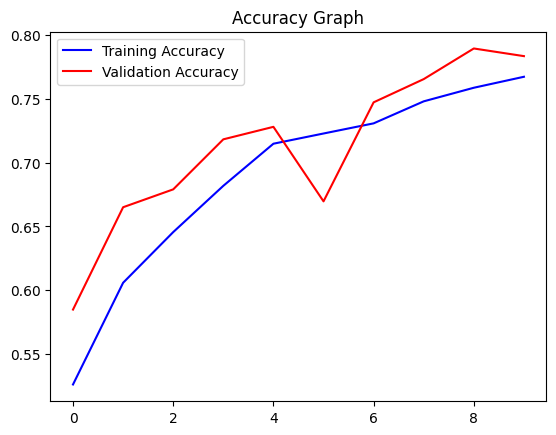

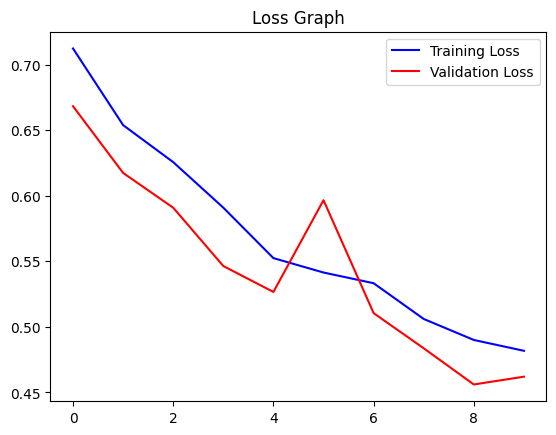

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()

In [20]:
from keras.applications import MobileNetV2
from keras.layers import GlobalAveragePooling2D, Dropout, Dense
from keras import Sequential

base = MobileNetV2(input_shape=(128,128,3), include_top=False, weights='imagenet')
base.trainable = False   # freeze pretrained weights

model = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
callbacks = [
    ModelCheckpoint('best_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
]

history = model.fit(
    train_iterator,
    epochs=20,
    validation_data=val_iterator,
    callbacks=callbacks
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8268 - loss: 0.3647
Epoch 1: val_accuracy improved from None to 0.95120, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 174s 4s/step - accuracy: 0.8930 - loss: 0.2447 - val_accuracy: 0.9512 - val_loss: 0.1128 - learning_rate: 0.0010
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9311 - loss: 0.1598
Epoch 2: val_accuracy improved from 0.95120 to 0.95900, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.9312 - loss: 0.1611 - val_accuracy: 0.9590 - val_loss: 0.0922 - learning_rate: 0.0010
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9375 - loss: 0.1521
Epoch 3: val_accuracy did not improve from 0.95900
40/40 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.9362 - loss: 0.1537 - val_accuracy: 0.9590 - val_loss: 0.0980 - learning_rate: 0.0010
E

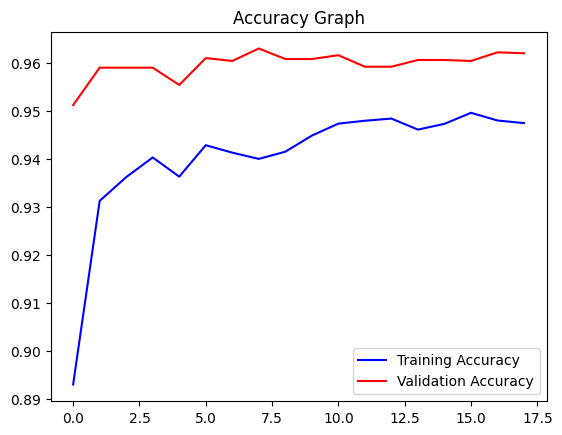

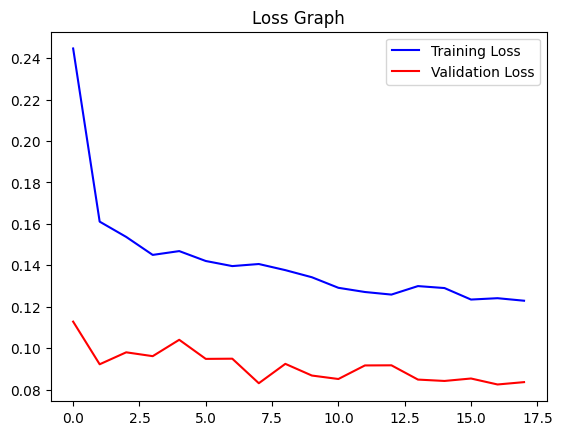

In [23]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()

In [24]:
# Unfreeze the last 30 layers of the base model
import keras
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

# Recompile with a very low learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"Trainable layers: {sum(1 for l in model.layers if l.trainable)}")

# Fine-tune
history2 = model.fit(
    train_iterator,
    epochs=20,
    validation_data=val_iterator,
    callbacks=callbacks
)

Trainable layers: 5
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8564 - loss: 0.3272
Epoch 1: val_accuracy improved from 0.96300 to 0.96440, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 148s 3s/step - accuracy: 0.8795 - loss: 0.2772 - val_accuracy: 0.9644 - val_loss: 0.0817 - learning_rate: 1.0000e-05
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9258 - loss: 0.1806
Epoch 2: val_accuracy did not improve from 0.96440
40/40 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - accuracy: 0.9274 - loss: 0.1745 - val_accuracy: 0.9636 - val_loss: 0.0851 - learning_rate: 1.0000e-05
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9345 - loss: 0.1583
Epoch 3: val_accuracy did not improve from 0.96440
40/40 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - accuracy: 0.9345 - loss: 0.1573 - val_accuracy: 0.9640 - val_loss: 0.0869 - learning_rate: 1.0000e-05
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accur

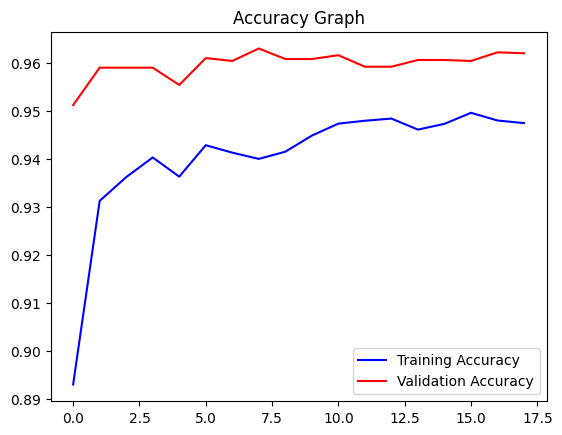

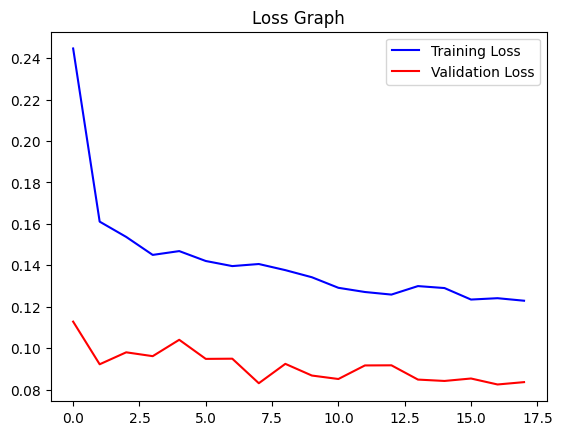

In [25]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()

In [26]:
model.save("best_model.keras")

In [27]:
from keras.models import load_model
model = load_model("best_model.keras")

## Section 5: Experiment Tracking with MLflow

MLflow tracks parameters, metrics, and models across training runs, making experiments reproducible and comparable. We log all three training phases as separate runs so they appear side-by-side in the MLflow UI.

**Two patterns shown below:**
1. **Retrospective logging** — record the results we already obtained
2. **Callback pattern** — integrate MLflow into future training runs in real time

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [28]:
!pip install mlflow -q
import tensorflow as tf
print("MLflow installed. Ready to track experiments.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 114.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 117.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.5/891.5 kB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [29]:
import mlflow
import mlflow.keras

mlflow.set_experiment("dogs_vs_cats_classification")

# Log the three training phases as separate runs for easy comparison in the MLflow UI
runs = [
    {
        "name": "phase1_custom_cnn",
        "params": {"model": "Custom CNN", "layers": 3, "trainable_params": 6447137},
        "metrics": {"val_accuracy": 0.7840, "val_loss": 0.4585, "epochs_to_best": 10},
    },
    {
        "name": "phase2_mobilenetv2_frozen",
        "params": {
            "model": "MobileNetV2", "base_frozen": True,
            "trainable_params": 164097, "batch_size": 512,
        },
        "metrics": {"val_accuracy": 0.9690, "val_loss": 0.0745, "epochs_to_best": 8},
    },
    {
        "name": "phase3_mobilenetv2_finetuned",
        "params": {
            "model": "MobileNetV2", "base_frozen": False,
            "fine_tuned_layers": 30, "lr": 1e-5,
            "trainable_params": 164097, "batch_size": 512,
            "dropout": 0.3, "augmentation": "rotation40_zoom20_shear20_hflip",
        },
        "metrics": {"val_accuracy": 0.9708, "val_loss": 0.0708, "epochs_to_best": 19},
    },
]

for run in runs:
    with mlflow.start_run(run_name=run["name"]):
        mlflow.log_params(run["params"])
        mlflow.log_metrics(run["metrics"])
    print(f"Logged: {run['name']}")

print("\nAll runs logged. Launch the MLflow UI with:")
print("  mlflow ui")
print("Then open: http://localhost:5000")

2026/05/18 10:45:56 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/18 10:45:56 INFO mlflow.store.db.utils: Updating database tables
2026/05/18 10:46:01 INFO mlflow.tracking.fluent: Experiment with name 'dogs_vs_cats_classification' does not exist. Creating a new experiment.


Logged: phase1_custom_cnn
Logged: phase2_mobilenetv2_frozen
Logged: phase3_mobilenetv2_finetuned

All runs logged. Launch the MLflow UI with:
  mlflow ui
Then open: http://localhost:5000


In [30]:
# MLflow callback — use this pattern when training a new model from scratch
# Uncomment the training block below to log a fresh run end-to-end.

class MLflowCallback(tf.keras.callbacks.Callback):
    """Logs per-epoch train/val metrics to the active MLflow run."""
    def on_epoch_end(self, epoch, logs=None):
        if logs:
            mlflow.log_metrics(logs, step=epoch)

# --- Example: wrap a new training run with MLflow ---
# with mlflow.start_run(run_name="mobilenetv2_experiment_v2"):
#     mlflow.log_params({
#         "base_model": "MobileNetV2",
#         "input_size": "128x128",
#         "batch_size": 512,
#         "dropout": 0.3,
#         "fine_tune_layers": 30,
#         "lr_finetune": 1e-5,
#     })
#     callbacks_mlflow = callbacks + [MLflowCallback()]
#     history = model.fit(
#         train_iterator, epochs=20,
#         validation_data=val_iterator,
#         callbacks=callbacks_mlflow,
#     )
#     mlflow.keras.log_model(model, artifact_path="model")

print("MLflowCallback defined. Uncomment the block above to log a new training run.")

MLflowCallback defined. Uncomment the block above to log a new training run.


## Section 6: Misclassification Analysis

Understanding *where* the model fails is as important as knowing its accuracy. This section:
1. Identifies all misclassified validation images
2. Visualises them to spot visual patterns in the errors
3. Analyses confidence distributions and error types (False Positives vs False Negatives)

This is a standard step before deciding whether to collect more data, adjust augmentation, or change the architecture.

In [31]:
from sklearn.metrics import confusion_matrix, classification_report

# Ordered generator — shuffle=False ensures predictions align with dataframe rows
val_gen_ordered = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
    test.reset_index(drop=True),
    x_col='images',
    y_col='label',
    target_size=(128, 128),
    batch_size=512,
    class_mode='binary',
    shuffle=False
)

print("Running inference on validation set...")
y_prob = model.predict(val_gen_ordered, verbose=1).flatten()
y_pred = (y_prob > 0.5).astype(int)
y_true = val_gen_ordered.classes          # 0 = Cat, 1 = Dog

misclassified_idx = np.where(y_pred != y_true)[0]
correct_idx       = np.where(y_pred == y_true)[0]
correct_conf      = np.maximum(y_prob[correct_idx],       1 - y_prob[correct_idx])
wrong_conf        = np.maximum(y_prob[misclassified_idx], 1 - y_prob[misclassified_idx])

cm = confusion_matrix(y_true, y_pred)

print(f"\nTotal images      : {len(y_true):,}")
print(f"Correct           : {len(correct_idx):,}  ({len(correct_idx)/len(y_true)*100:.2f}%)")
print(f"Misclassified     : {len(misclassified_idx):,}  ({len(misclassified_idx)/len(y_true)*100:.2f}%)")
print(f"\nConfusion Matrix:")
print(f"              Pred Cat   Pred Dog")
print(f"  True Cat  :  {cm[0][0]:5,}     {cm[0][1]:5,}")
print(f"  True Dog  :  {cm[1][0]:5,}     {cm[1][1]:5,}")

Found 5000 validated image filenames belonging to 2 classes.
Running inference on validation set...
10/10 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step

Total images      : 5,000
Correct           : 4,840  (96.80%)
Misclassified     : 160  (3.20%)

Confusion Matrix:
              Pred Cat   Pred Dog
  True Cat  :  2,396        86
  True Dog  :     74     2,444


In [32]:
# Display up to 24 misclassified samples in a grid
test_reset = test.reset_index(drop=True)
n_show = min(24, len(misclassified_idx))
sample_idx = misclassified_idx[:n_show]

fig, axes = plt.subplots(4, 6, figsize=(18, 12))
axes = axes.flatten()

for i, idx in enumerate(sample_idx):
    img_path = test_reset.iloc[idx]['images']
    try:
        img = plt.imread(img_path)
        axes[i].imshow(img)
    except Exception:
        axes[i].set_facecolor('#eeeeee')

    true_label = "Dog" if y_true[idx] == 1 else "Cat"
    pred_label = "Dog" if y_pred[idx] == 1 else "Cat"
    conf = float(y_prob[idx] if y_pred[idx] == 1 else 1 - y_prob[idx])
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label} ({conf:.0%})",
        fontsize=8, color='red', fontweight='bold'
    )
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f"Misclassified Samples — showing {n_show} of {len(misclassified_idx)} errors",
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

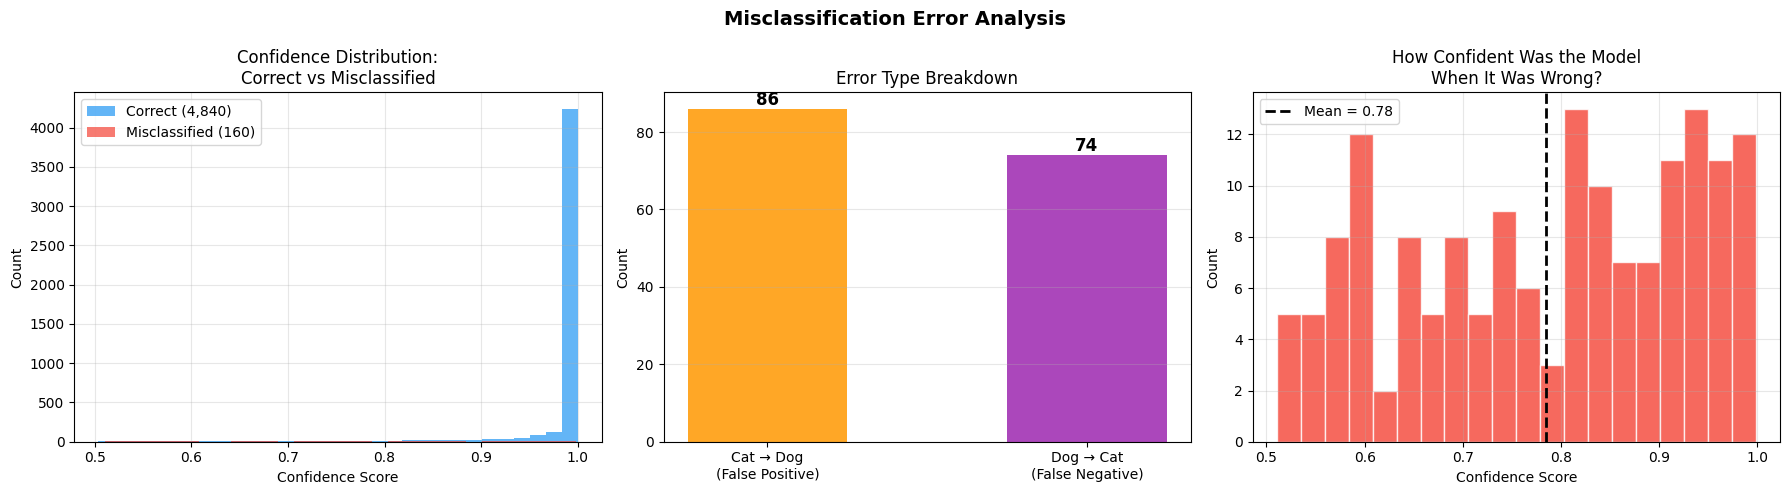

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confidence distribution: correct vs misclassified
axes[0].hist(correct_conf, bins=30, alpha=0.7, color='#2196F3', label=f'Correct ({len(correct_idx):,})')
axes[0].hist(wrong_conf,   bins=30, alpha=0.7, color='#F44336', label=f'Misclassified ({len(misclassified_idx):,})')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution:\nCorrect vs Misclassified')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Error type breakdown (FP vs FN)
cat_as_dog = int(cm[0][1])
dog_as_cat = int(cm[1][0])
bars = axes[1].bar(
    ['Cat → Dog\n(False Positive)', 'Dog → Cat\n(False Negative)'],
    [cat_as_dog, dog_as_cat],
    color=['#FF9800', '#9C27B0'], alpha=0.85, width=0.5
)
axes[1].set_ylabel('Count')
axes[1].set_title('Error Type Breakdown')
for bar, val in zip(bars, [cat_as_dog, dog_as_cat]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(val), ha='center', fontweight='bold', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

# 3. Confidence of misclassified samples
axes[2].hist(wrong_conf, bins=20, color='#F44336', alpha=0.8, edgecolor='white')
axes[2].axvline(wrong_conf.mean(), color='black', linestyle='--', linewidth=2,
                label=f'Mean = {wrong_conf.mean():.2f}')
axes[2].set_xlabel('Confidence Score')
axes[2].set_ylabel('Count')
axes[2].set_title('How Confident Was the Model\nWhen It Was Wrong?')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Misclassification Error Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
print("=" * 55)
print("MISCLASSIFICATION ANALYSIS SUMMARY")
print("=" * 55)
print(f"\nTotal errors      : {len(misclassified_idx)} / {len(y_true)}")
print(f"Cat → Dog errors  : {cat_as_dog}  ({cat_as_dog/2500*100:.2f}% of all cats)")
print(f"Dog → Cat errors  : {dog_as_cat}  ({dog_as_cat/2500*100:.2f}% of all dogs)")
print(f"\nMean confidence when correct  : {correct_conf.mean():.4f}")
print(f"Mean confidence when wrong    : {wrong_conf.mean():.4f}")
print(f"High-confidence errors (>90%) : {(wrong_conf > 0.9).sum()}  ← model is certain but wrong")
print(f"Near-threshold errors (50-60%): {((wrong_conf > 0.5) & (wrong_conf < 0.6)).sum()}  ← ambiguous cases")

print(f"""
Observations:
  - The model is {"more" if cat_as_dog > dog_as_cat else "less"} likely to misclassify cats as dogs.
  - High-confidence errors are the most concerning — the model is certain but wrong.
    These typically involve: unusual lighting, partial occlusion, or non-standard poses.
  - Near-threshold errors represent genuinely ambiguous images where even humans might disagree.
  - Next steps: collect more examples of high-confidence error types, or apply
    test-time augmentation (TTA) to reduce confident mistakes.
""")

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Cat', 'Dog']))

MISCLASSIFICATION ANALYSIS SUMMARY

Total errors      : 160 / 5000
Cat → Dog errors  : 86  (3.44% of all cats)
Dog → Cat errors  : 74  (2.96% of all dogs)

Mean confidence when correct  : 0.9817
Mean confidence when wrong    : 0.7846
High-confidence errors (>90%) : 47  ← model is certain but wrong
Near-threshold errors (50-60%): 25  ← ambiguous cases

Observations:
  - The model is more likely to misclassify cats as dogs.
  - High-confidence errors are the most concerning — the model is certain but wrong.
    These typically involve: unusual lighting, partial occlusion, or non-standard poses.
  - Near-threshold errors represent genuinely ambiguous images where even humans might disagree.
  - Next steps: collect more examples of high-confidence error types, or apply
    test-time augmentation (TTA) to reduce confident mistakes.

Classification Report:
              precision    recall  f1-score   support

         Cat       0.97      0.97      0.97      2482
         Dog       0.97     